In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('data/criteo/criteo-uplift-v2.1.csv')

Как было выявлено ранее, главной проблемой данной рекламной кампании является число посещений, на которое должно оказывать влияние воздействие рекламой. Разумно использовать методы оценки ITT (Intention-To-Treat) и TOT (Treatment-On-Treat), чтобы определить, как именно влияет воздействие рекламой на посещения и конверсию.

    Анализ по «намерению лечить» (ITT) использует данные всех рандомизированных участников независимо от того, увидел пользователь рекламу (exposure = 1) или не получил воздействия (exposure = 0).
    
    Анализ по «воздействию на прошедших лечение» (TOT) оценивает эффект лечения только на тех, кто действительно получил воздействие (exposure = 1)
    
Это напрямую проверит гипотезу: visit является слабой частью воронки из-за малого exposure.

In [4]:
def itt_tot(df, outcome, treatment="treatment", exposure="exposure"):
    """
    Функция для ITT и TOT оценивания
    ---
    outcome - целевая метрика (visit или conversion)
    treatment - метка экспериментальной группы (факт лечения)
    exposure - фактическое воздействие
    """

    # мат. ожидания подгрупп
    exp = df.groupby(treatment)[outcome].mean()
    control_exp = exp.loc[0]
    treatment_exp = exp.loc[1]

    # ITT
    itt = treatment_exp - control_exp

    # доля с воздействием в treatment
    exposure_exp = df.loc[df[treatment] == 1, exposure].mean()

    # TOT
    tot = itt / exposure_exp if exposure_exp > 0 else float("nan")

    return {
        "метрика": outcome,
        "контр. доля": control_exp,
        "эксп. доля": treatment_exp,
        "ITT": itt,
        "TOT": tot
    }

In [5]:
results = pd.DataFrame([
    itt_tot(df, "visit"),
    itt_tot(df, "conversion")
])

results

,метрика,контр. доля,эксп. доля,ITT,TOT
0,visit,0.038201,0.048543,0.010342,0.286996
1,conversion,0.001938,0.003089,0.001152,0.031964


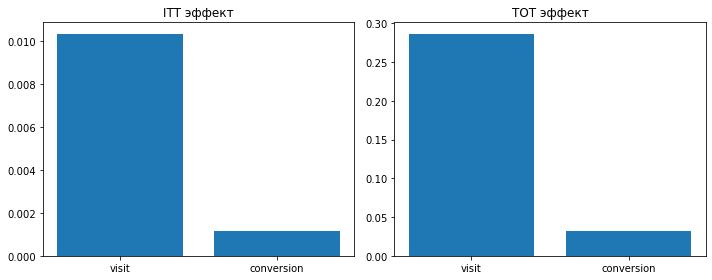

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(results["метрика"].tolist(), results["ITT"])
ax[0].set_title('ITT эффект')
ax[1].bar(results["метрика"].tolist(), results["TOT"]) 
ax[1].set_title('TOT эффект')
plt.tight_layout()
plt.show()

### **РЕЗУЛЬТАТЫ ITT TOT**

**visit**

    При назначении treatment доля посещений возросла с 3.82% до 4.85%
    Абсолютный прирост посещений +1.03 п.п.
    Прирост посещений среди реально получивших воздействие +28.7 п.п.
    
**conversion**

    При назначении лечения конверсия выросла с 0.19% до 0.31%
    Абсолютный прирост конверсии +0.11 п.п.
    Прирост конверсии среди реально получивших воздействие +3.2 п.п.

Для visit и для conversion оценки ITT и TOT являются строго положительными, что указывает на эффективность рекламы.
TOT превышает ITT как для visit, так и для conversion с одинаковым соотношением TOT/ITT = 27.7. Такое соотношение для обеих метрик указывает на низкий охват как основную причину слабого ITT: реклама значительно увеличивает вероятность посещения и конверсии среди увидевших её пользователей (TOT), но низкая видимость (exposure ~3.6%) делает эффект незначительным по всей treatment-группе (ITT).

Это подтверждает гипотезу - необходимо концентрироваться на росте числа exposure для значительного повышения числа конверсий.